In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [45]:
def up_and_out_european_option(S, K, H, T, r, q, sigma, rebate=0.0, option_type='call'):
    if S >= H:
        return rebate * np.exp(-r * T)

    b = r - q
    sqrtT = sigma * np.sqrt(T)
    H_S = H / S
    mu = b / sigma**2 - 0.5

    log_S_K   = np.log(S / K)
    log_S_H   = np.log(S / H)
    log_H_S   = np.log(H / S)
    log_H2_SK = np.log(H**2 / (S * K))

    d1 = (log_S_K + (b + 0.5*sigma**2)*T) / sqrtT
    d2 = d1 - sqrtT
    e1 = (log_S_H + (b + 0.5*sigma**2)*T) / sqrtT
    e2 = e1 - sqrtT
    f1 = (log_S_H + (b - 0.5*sigma**2)*T) / sqrtT
    f2 = f1 - sqrtT
    g1 = (log_H2_SK + (b + 0.5*sigma**2)*T) / sqrtT
    g2 = g1 - sqrtT
    h1 = (log_H_S + (b + 0.5*sigma**2)*T) / sqrtT
    h2 = h1 - sqrtT

    if option_type.lower() == 'call':
        if H > K:
            A = S * np.exp((b - r) * T) * norm.cdf(d1)
            B = K * np.exp(-r * T) * norm.cdf(d2)
            C = S * np.exp((b - r) * T) * norm.cdf(e1)
            D = K * np.exp(-r * T) * norm.cdf(e2)
            E = S * np.exp((b - r) * T) * (H_S)**(2*mu + 2) * (norm.cdf(-g1) - norm.cdf(-h1))
            F = K * np.exp(-r * T) * (H_S)**(2*mu)     * (norm.cdf(-g2) - norm.cdf(-h2))
            price = (A - B) - (C - D) + (E - F)
        else:
            E = S * np.exp((b - r) * T) * (H_S)**(2*mu + 2) * (norm.cdf(-g1) - norm.cdf(-h1))
            F = K * np.exp(-r * T) * (H_S)**(2*mu)     * (norm.cdf(-g2) - norm.cdf(-h2))
            price = E - F

    elif option_type.lower() == 'put':
        if H > K:
            A = K * np.exp(-r * T) * norm.cdf(-d2)
            B = S * np.exp((b - r) * T) * norm.cdf(-d1)
            C = K * np.exp(-r * T) * norm.cdf(-f2)
            D = S * np.exp((b - r) * T) * norm.cdf(-f1)
            E = K * np.exp(-r * T) * (H_S)**(2*mu)     * (norm.cdf(h2) - norm.cdf(g2))
            F = S * np.exp((b - r) * T) * (H_S)**(2*mu + 2) * (norm.cdf(h1) - norm.cdf(g1))
            price = (A - B) - (C - D) + (E - F)
        else:
            price = 0.0
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    price = max(price, 0.0)

    if rebate != 0.0:
        H_S_ratio = H / S
        
        a1 = (np.log(H/S) + (b + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        a2 = a1 - sigma * np.sqrt(T)
        
        prob_hit = norm.cdf(-a2) + (H_S_ratio)**(1 - (2*b)/(sigma**2)) * norm.cdf(-a1)
        if prob_hit < 0:
            print("Warning: Negative probability of hitting the barrier computed.")
        if prob_hit > 1:
            print("Warning: Probability of hitting the barrier exceeds 1.")
        rebate_value = rebate * np.exp(-r * T) * prob_hit
        price += rebate_value

    return price

In [46]:
class Path:
    def __init__(self,price,days,vol,interest,seed=87,antithetic=True):
        self.paths = []
        self.antipaths = []
        self.price = price
        self.days = days
        self.vol = vol
        self.hourly_vol = vol/np.sqrt(252*24)
        self.drift = interest/(252*24) - 0.5*self.hourly_vol**2
        self.antithetic = antithetic
        np.random.seed(seed)

    def add_path(self, path):
        self.paths.append(path)

    def generate_path(self):
        path = [self.price]
        antipath = [self.price]
        for _ in range(self.days*24):
            Z = np.random.normal(0,1)
            step_change = np.exp(self.drift + self.hourly_vol * Z)
            path.append(path[-1] * step_change)
            
            if self.antithetic:
                antistep_change = np.exp(self.drift + self.hourly_vol * -Z)
                antipath.append(antipath[-1] * antistep_change)
        
        self.add_path(path)
        if self.antithetic:
            self.antipaths.append(antipath)
    
    def make_paths(self,amount=10000,reset=False):
        if reset == True:
            self.paths = []
            self.antipaths = []
        for _ in range(amount):
            self.generate_path()

    def get_paths(self):
        return np.array(self.paths)
    
    def get_antipaths(self):
        return np.array(self.antipaths)

In [47]:
final_path_list = []
paths = Path(price=100,days=126,vol=0.3,interest=0.02)
paths.make_paths(amount=20000)
final_paths = paths.get_paths()
final_antipaths = paths.get_antipaths()

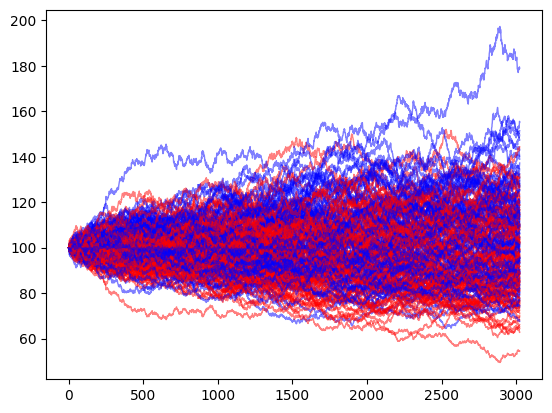

In [48]:
for i in range(100):
    plt.plot(final_paths[i],alpha=0.5,lw=1,c='r')
    plt.plot(final_antipaths[i],alpha=0.5,lw=1,c='b')
plt.show()

In [ ]:
class Monte:
    def __init__(self,paths,antipaths,barrier_type,rebate=0,interval=1):
        self.paths = np.array(paths)
        self.antipaths = antipaths
        self.barrier_type = barrier_type
        self.rebate = rebate
        self.interval = interval
        self.adj = True if interval == 1 else False
        self.discount = np.exp(-0.15 * np.sqrt(self.interval / (252*24)))

    def barrier(self,type,time,cust=110):
        if type == 1:
            barrier_level = 1000000 if time < 63*24 else 110
        elif type == 2:
            barrier_level = 108 if time < 63*24 else 110
        elif type == 3:
            weight = time / (126*24)
            barrier_level = 105*(1-weight) + 115*weight
        elif type == 0:
            barrier_level = cust
        else:
            return ValueError
        if self.adj == True:
            barrier_level *= self.discount
        return barrier_level

    def simple(self, interval=None, print_=True):
        if interval is None:
            interval = self.interval
        payoffs = []
        for path in self.paths:
            for i in range(len(path)):
                if path[i] >= self.barrier(self.barrier_type,i) and (i + 1) % interval == 0:
                    payoffs.append(self.rebate*np.exp(0.02*-0.5))
                    break
                if i == len(path) - 1:
                    payoffs.append(max(path[-1]-105,0)*np.exp(0.02*-0.5))
        if print_:
            print("Mean payoff:",np.mean(payoffs))
            print("Standard Error:",np.std(payoffs)/np.sqrt(len(payoffs)))
            print("--------------")
        return np.array(payoffs)
    
    def simple_barrier(self, cust=110):
        payoffs = []
        for path in self.paths:
            for i in range(len(path)):
                if path[i] >= self.barrier(0,i,cust=cust):
                    payoffs.append(self.rebate*np.exp(0.02*-0.5))
                    break
                if i == len(path) - 1:
                    payoffs.append(max(path[-1]-105,0)*np.exp(0.02*-0.5))
        return np.array(payoffs)
    
    def antithetic(self, interval=None):
        if interval is None:
            interval = self.interval
        payoffs_1 = []
        for path in self.paths:
            for i in range(len(path)):
                if path[i] >= self.barrier(self.barrier_type,i) and (i + 1) % interval == 0:
                    payoffs_1.append(self.rebate*np.exp(0.02*-0.5))
                    break
                if i == len(path) - 1:
                    payoffs_1.append(max(path[-1]-105,0)*np.exp(0.02*-0.5))
        payoffs_2 = []
        for path in self.antipaths:
            for i in range(len(path)):
                if path[i] >= self.barrier(self.barrier_type,i) and (i + 1) % interval == 0:
                    payoffs_2.append(self.rebate*np.exp(0.02*-0.5))
                    break
                if i == len(path) - 1:
                    payoffs_2.append(max(path[-1]-105,0)*np.exp(0.02*-0.5))
        print("Corr:",np.corrcoef(payoffs_1,payoffs_2)[0][1])
        payoffs = (np.array(payoffs_1) + np.array(payoffs_2))/2
        print("Mean payoff:",np.mean(payoffs))
        print("Standard Error:",np.std(payoffs)/np.sqrt(len(payoffs)))
        print("--------------")
        return payoffs
    
    def control_variate(self, interval=None):
        if interval is None:
            interval = self.interval
        payoffs = self.simple(interval=interval,print_=False)
        if self.adj == True:
            control_payoffs = self.simple_barrier(cust=110)
        else:
            control_payoffs = self.simple_barrier(cust=110*np.exp(0.15*np.sqrt((interval)/252/24)-0.15*np.sqrt(1/252/24)))
        cov = np.cov(payoffs,control_payoffs)[0][1]
        sample_variance = np.var(control_payoffs)
        if sample_variance == 0:
            sample_variance = 10**-7
        w = cov / sample_variance
        adjusted_payoffs = []
        if self.adj == True:
            adjusted_payoffs = payoffs - w * (control_payoffs - up_and_out_european_option(S=100,K=105,H=110,T=0.5,r=0.02,
                                                                                           q=0.0,sigma=0.3,rebate=self.rebate))
        else:
            adjusted_payoffs = payoffs - w * (control_payoffs - up_and_out_european_option(S=100,K=105,
                                                                                           H=110*np.exp(0.15*np.sqrt(interval/252/24)),
                                                                                           T=0.5,r=0.02,q=0.0,sigma=0.3,rebate=self.rebate))
        print("Corr:",np.corrcoef(payoffs,control_payoffs)[0][1])
        print("Mean payoff:",np.mean(adjusted_payoffs))
        print("Standard Error:",np.std(adjusted_payoffs)/np.sqrt(len(adjusted_payoffs)))
        print("--------------")
        return adjusted_payoffs

In [50]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=0)
monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=0)
monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=0)
monte.simple()

Mean payoff: 0.017388348423199092
Standard Error: 0.0014206570145024622
--------------
Mean payoff: 0.010675581303392445
Standard Error: 0.001138130277171304
--------------
Mean payoff: 0.04897905250675176
Standard Error: 0.0035021714643458258
--------------


array([0., 0., 0., ..., 0., 0., 0.])

In [51]:
payoffs = Monte(final_paths,final_antipaths,barrier_type=1,rebate=0).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=2,rebate=0).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=3,rebate=0).antithetic()

Corr: -0.007387876349528973
Mean payoff: 0.017647289394829135
Standard Error: 0.001023139172836821
--------------
Corr: -0.004319259642149968
Mean payoff: 0.010762777523496518
Standard Error: 0.0008172699208354597
--------------
Corr: -0.009642958950159437
Mean payoff: 0.04790539834331306
Standard Error: 0.002427391894808858
--------------


In [52]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=0)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=0)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=0)
payoffs = monte.control_variate()

Corr: 0.8488095552618272
Mean payoff: 0.017468134714250374
Standard Error: 0.0007510995507262927
--------------
Corr: 0.9411786224384494
Mean payoff: 0.0107464562603387
Standard Error: 0.0003845849869006604
--------------
Corr: 0.27880868305771533
Mean payoff: 0.049043658450831154
Standard Error: 0.003363298688721888
--------------


In [53]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=4)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=4)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=4)
payoffs = monte.simple()

Mean payoff: 2.1012452384984486
Standard Error: 0.013924663011559422
--------------
Mean payoff: 2.7190559065076165
Standard Error: 0.012958552617229922
--------------
Mean payoff: 2.873393218226379
Standard Error: 0.012602693285934413
--------------


In [54]:
payoffs = Monte(final_paths,final_antipaths,barrier_type=1,rebate=4).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=2,rebate=4).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=3,rebate=4).antithetic()

Corr: -0.7684686691331505
Mean payoff: 2.096454925317958
Standard Error: 0.004738948470509128
--------------
Corr: -0.4514021394705596
Mean payoff: 2.717658027977097
Standard Error: 0.006789527410254155
--------------
Corr: -0.3656103638328853
Mean payoff: 2.8754877235309375
Standard Error: 0.007090109626414948
--------------


In [55]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=4)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=4)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=4)
payoffs = monte.control_variate()

Corr: 0.7996134067815053
Mean payoff: 2.1041663973209217
Standard Error: 0.008361970585960247
--------------
Corr: 0.8980892145719374
Mean payoff: 2.7221091847754604
Standard Error: 0.005699344170321342
--------------
Corr: 0.7690671685955105
Mean payoff: 2.8759360524499034
Standard Error: 0.0080552378623489
--------------


In [56]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=8)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=8)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=8)
payoffs = monte.simple()

Mean payoff: 4.185102128573698
Standard Error: 0.02787072167736497
--------------
Mean payoff: 5.427436231711842
Standard Error: 0.025953670819810228
--------------
Mean payoff: 5.697807383946006
Standard Error: 0.025023655274260585
--------------


In [57]:
payoffs = Monte(final_paths,final_antipaths,barrier_type=1,rebate=8).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=2,rebate=8).antithetic()
payoffs = Monte(final_paths,final_antipaths,barrier_type=3,rebate=8).antithetic()

Corr: -0.7698406066848656
Mean payoff: 4.175262561241086
Standard Error: 0.009455916358416671
--------------
Corr: -0.45405970493710335
Mean payoff: 5.4245532784306985
Standard Error: 0.01356426556076228
--------------
Corr: -0.38727291772398825
Mean payoff: 5.703070048718562
Standard Error: 0.013841076392617054
--------------


In [58]:
monte = Monte(final_paths,final_antipaths,barrier_type=1,rebate=8)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=2,rebate=8)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=3,rebate=8)
payoffs = monte.control_variate()

Corr: 0.7987205481187807
Mean payoff: 4.190868882358441
Standard Error: 0.01676987339371299
--------------
Corr: 0.8978511388223829
Mean payoff: 5.433472818758104
Standard Error: 0.011427378996216781
--------------
Corr: 0.7672565721556984
Mean payoff: 5.702781085287091
Standard Error: 0.016048678064713343
--------------


In [59]:
# trading month, week and day
month = 24 * 21
week = 24 * 5
day = 24

monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=month)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=week)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=day)
payoffs = monte.simple()

Mean payoff: 0.07495596387640335
Standard Error: 0.003356732680182908
--------------
Mean payoff: 0.0485394824379231
Standard Error: 0.003056986364423129
--------------
Mean payoff: 0.0215216018766223
Standard Error: 0.0017075260818899217
--------------


In [60]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=month)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=week)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=day)
payoffs = monte.antithetic()

Corr: -0.02502332843027479
Mean payoff: 0.07716668196615793
Standard Error: 0.002409163818137175
--------------
Corr: -0.013129722636990446
Mean payoff: 0.050806986483896546
Standard Error: 0.0022015195522435724
--------------
Corr: -0.008428781897655195
Mean payoff: 0.024062099657333223
Standard Error: 0.0013052340924014205
--------------


In [61]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=month)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=week)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=0,interval=day)
payoffs = monte.control_variate()

Corr: 0.4142216853541548
Mean payoff: 0.07514958792091359
Standard Error: 0.0030552176065946433
--------------
Corr: 0.6700059673002747
Mean payoff: 0.051195698126864975
Standard Error: 0.0022693712927704963
--------------
Corr: 0.869708736729925
Mean payoff: 0.022748181381846668
Standard Error: 0.0008427756397878485
--------------


In [62]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=month)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=week)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=day)
payoffs = monte.simple()

Mean payoff: 1.9744655749075573
Standard Error: 0.013883252274188372
--------------
Mean payoff: 2.2371436449238344
Standard Error: 0.013877601476525536
--------------
Mean payoff: 2.391304883938631
Standard Error: 0.013647804247411875
--------------


In [63]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=month)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=week)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=day)
payoffs = monte.antithetic()

Corr: -0.6595186885047642
Mean payoff: 1.9797454474819347
Standard Error: 0.005731496072328644
--------------
Corr: -0.6342325167045477
Mean payoff: 2.241589258604056
Standard Error: 0.00593356219036226
--------------
Corr: -0.601803478797095
Mean payoff: 2.391964287035219
Standard Error: 0.00608964597608006
--------------


In [64]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=month)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=week)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=4,interval=day)
payoffs = monte.control_variate()

Corr: 0.905138269991598
Mean payoff: 2.0090782516474266
Standard Error: 0.005902010648309327
--------------
Corr: 0.9423390427622197
Mean payoff: 2.2612296206835323
Standard Error: 0.004644274276566696
--------------
Corr: 0.9711304415976133
Mean payoff: 2.410117276465849
Standard Error: 0.003255671267143207
--------------


In [65]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=month)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=week)
payoffs = monte.simple()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=day)
payoffs = monte.simple()

Mean payoff: 3.8739751859387113
Standard Error: 0.027670412478563975
--------------
Mean payoff: 4.425747807409745
Standard Error: 0.027632635356222512
--------------
Mean payoff: 4.76108816600064
Standard Error: 0.027322218314181124
--------------


In [66]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=month)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=week)
payoffs = monte.antithetic()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=day)
payoffs = monte.antithetic()

Corr: -0.6537777853631216
Mean payoff: 3.8823242129977107
Standard Error: 0.011511555760331083
--------------
Corr: -0.6451434436711794
Mean payoff: 4.432371530724215
Standard Error: 0.01163398297010299
--------------
Corr: -0.6071307920522089
Mean payoff: 4.759866474413104
Standard Error: 0.012106367254467074
--------------


In [67]:
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=month)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=week)
payoffs = monte.control_variate()
monte = Monte(final_paths,final_antipaths,barrier_type=0,rebate=8,interval=day)
payoffs = monte.control_variate()

Corr: 0.9056360565052438
Mean payoff: 3.944049052383488
Standard Error: 0.011733799346727468
--------------
Corr: 0.9413776966885166
Mean payoff: 4.470517211651702
Standard Error: 0.009321992890013777
--------------
Corr: 0.9704502751217756
Mean payoff: 4.797294291201011
Standard Error: 0.006592883881837414
--------------
